In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
xline = np.arange(0,1,0.01)
center=0.3
divisor= 0.01
share = 0.4
rlen = 10
spacing = rlen*3
middle = spacing//2
crashing_point = int(spacing*share)
lx = len(xline)

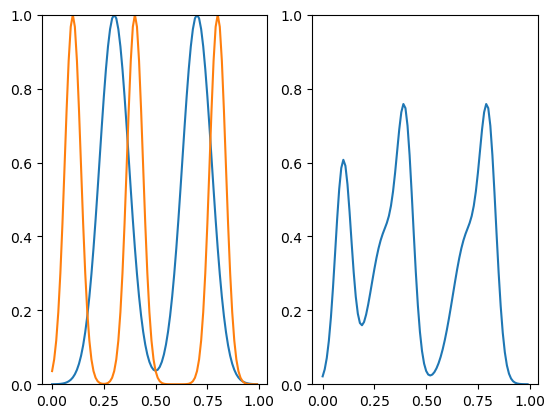

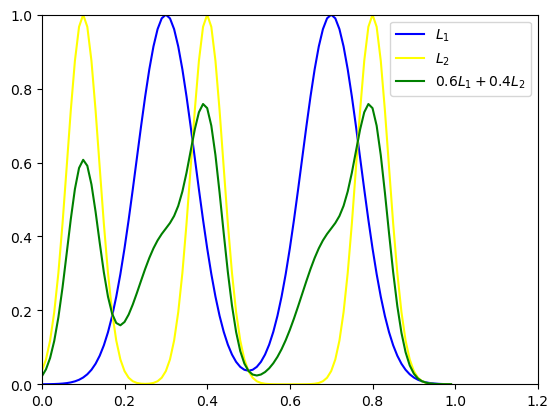

In [4]:

def get_gauss(center,divisor):
    return  np.exp(-(xline-center)**2/divisor)
obj1 = get_gauss(0.3,0.01)
obj1 += get_gauss(0.7,0.01)
obj2 = get_gauss(0.1, 0.003)
obj2 += get_gauss(0.4, 0.003)
obj2 += get_gauss(0.8, 0.003)


fig, axs = plt.subplots(1,2)
ax =axs[0] 
ax.plot(xline,obj1)
ax.plot(xline,obj2)
ax.set_ylim(0,1)
ax =axs[1] 
ax.set_ylim(0,1)
obj_mix = share*obj1+(1-share)*obj2
ax.plot(xline,obj_mix)

fig, ax = plt.subplots(1,1)
# ax =axs[0] 
ax.plot(xline,obj1,color="blue", label = "$L_1$")
ax.plot(xline,obj2, color="yellow", label= "$L_2$" )
ax.set_ylim(0,1,)
ax.set_xlim(0,1.2)
obj_mix = share*obj1+(1-share)*obj2
ax.plot(xline,obj_mix, color="green", label="$0.6L_1 + 0.4 L_2$")
ax.legend()

In [5]:
combi = share*obj1+(1-share)*obj2
padding = rlen*len(combi)
mixed = np.pad(np.array([combi for ii in range(rlen)]).flatten(),padding)
ordered_list = np.array([obj1 if ii < share*rlen else obj2 for ii in range(rlen)])
mix = np.arange(rlen)
np.random.shuffle(mix)

ordered = np.pad((ordered_list).flatten(),padding)
unordered = np.pad((ordered_list[mix]).flatten(),padding)
np.random.shuffle(mix)
unordered2 = np.pad((ordered_list[mix]).flatten(),padding)
xdiff = xline[1]-xline[0]
xrange = np.arange(0,rlen*3, xdiff)

In [6]:
np.sum(mixed), np.sum(ordered), np.sum(unordered), 
print(crashing_point)

12


(13.0, 17.0)

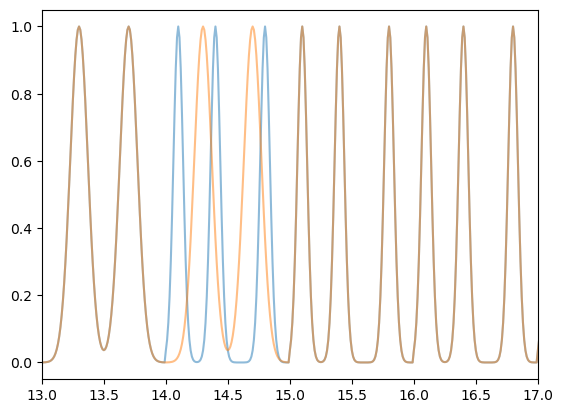

In [7]:
plt.plot(xrange, ordered, alpha=0.5)
plt.plot(xrange, unordered, alpha=0.5)
plt.xlim(middle-2, middle+2)
# plt.xlim(-2, middle+2)

3000


(0.0, 40000.0)

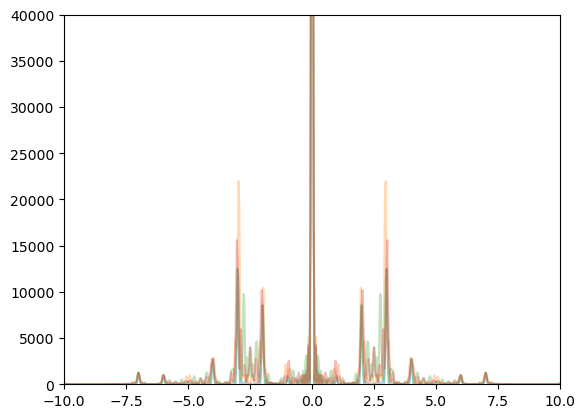

In [32]:
print(len(unordered))
ints_mixed = np.abs(np.fft.fft(mixed))**2
ints_ordered = np.abs(np.fft.fft(ordered))**2
ints_unordered = np.abs(np.fft.fft(unordered))**2
ints_unordered2 = np.abs(np.fft.fft(unordered2))**2
diff  =xline[1]-xline[0]
freq = np.fft.fftshift(np.fft.fftfreq(len(ints_mixed),diff))
plt.plot(freq,np.fft.fftshift(ints_mixed), alpha= 0.3)
plt.plot(freq,np.fft.fftshift(ints_ordered), alpha= 0.3)
plt.plot(freq,np.fft.fftshift(ints_unordered), alpha= 0.3)
plt.plot(freq,np.fft.fftshift(ints_unordered2), alpha= 0.3)
# plt.plot(np.fft.fftshift(ints_comb), label = "|I1|^2+ |I2|^2 + 2|I1||I2| ")
lx = len(xline)
plt.xlim(middle*lx-2*lx, middle*lx+2*lx)
plt.xlim(-5,5)
plt.xlim(-10,10)
plt.ylim(0,40000)



(40.0, 60.0)

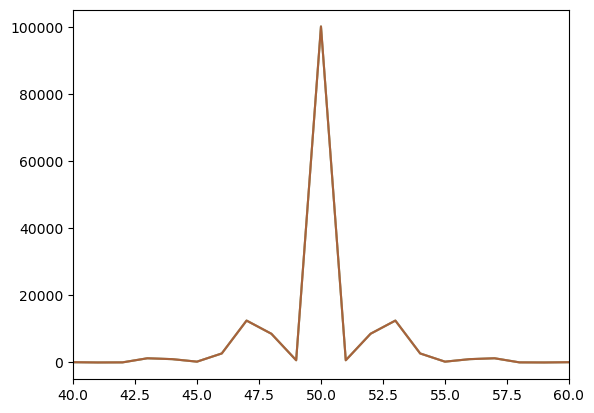

In [ ]:
plt.plot(np.fft.fftshift(ints_mixed)[::spacing], alpha= 0.5)
plt.plot(np.fft.fftshift(ints_ordered)[::spacing], alpha= 0.5)
plt.plot(np.fft.fftshift(ints_unordered)[::spacing], alpha= 0.5)
plt.plot(np.fft.fftshift(ints_unordered2)[::spacing], alpha= 0.5)
plt.xlim(40,60)
# plt.ylim(0,2e6)

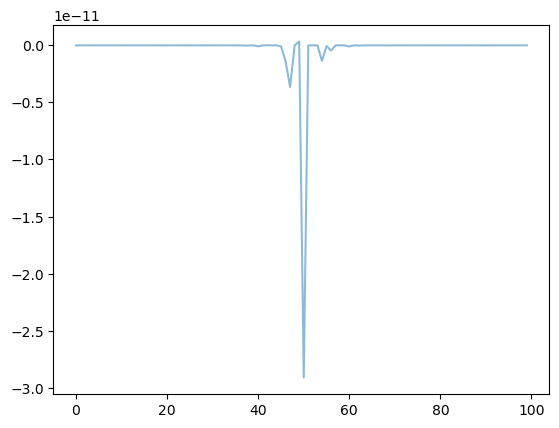

In [10]:
plt.plot(np.fft.fftshift(ints_mixed-ints_ordered)[::spacing], alpha= 0.5)


freq [-50.         -49.96666667 -49.93333333 ...  49.9         49.93333333
  49.96666667]


Text(0.5, 0, 'Arbitrary Frequency Units')

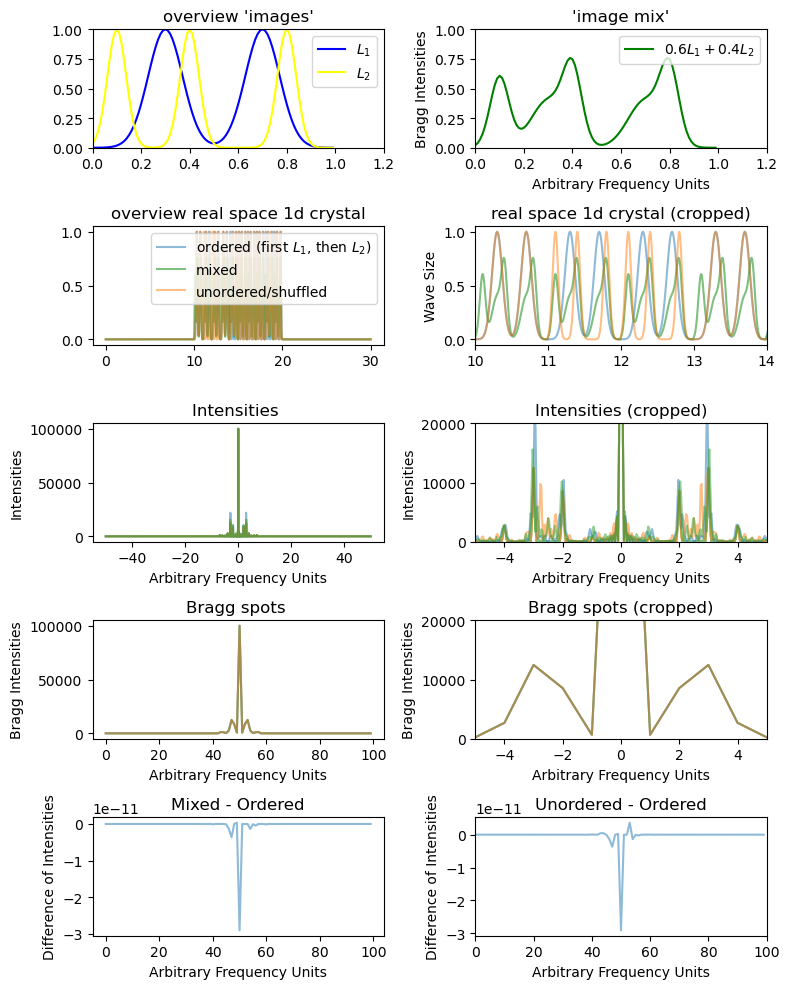

In [43]:
fig, axs = plt.subplots(5,2, figsize=(8,10),tight_layout=True)
ax =axs[0,0] 
ax.set_title("overview 'images'")
ax.plot(xline,obj1,color="blue", label = "$L_1$")
ax.plot(xline,obj2, color="yellow", label= "$L_2$" )
ax.set_ylim(0,1,)
ax.set_xlim(0,1.2)
ax.legend()
ax =axs[0,1] 
ax.set_title("'image mix'")
ax.set_ylim(0,1,)
ax.set_xlim(0,1.2)
ax.set_ylabel("Bragg Intensities")
ax.set_xlabel("Arbitrary Frequency Units")
obj_mix = share*obj1+(1-share)*obj2
ax.plot(xline,obj_mix, color="green", label="$0.6L_1 + 0.4 L_2$")
ax.legend()
ax = axs[1,0]
ax.set_title("overview real space 1d crystal")
ax.plot(xrange, ordered, alpha=0.5, label="ordered (first $L_1$, then $L_2$)")
ax.plot(xrange, mixed, alpha=0.5, label="mixed", color="green" )
ax.plot(xrange, unordered, alpha=0.5, label = "unordered/shuffled")
ax.legend()
ax = axs[1,1]
ax.set_title("real space 1d crystal (cropped)")
ax.plot(xrange, ordered, alpha=0.5, label="ordered (first $L_1$, then $L_2$)")
ax.plot(xrange, mixed, alpha=0.5, label="mixed", color="green" )
ax.plot(xrange, unordered, alpha=0.5, label = "unordered/shuffled")
ax.set_ylabel("Wave Size")
ax.set_xlim(crashing_point-2,crashing_point+2)
ax = axs[2,0]
ax.set_title("Intensities ")
print('freq', freq)
ax.plot(freq,np.fft.fftshift(ints_mixed),c="g", alpha= 0.5)
ax.plot(freq,np.fft.fftshift(ints_ordered), alpha= 0.5)
ax.plot(freq,np.fft.fftshift(ints_unordered), alpha= 0.5)
ax.plot(freq,np.fft.fftshift(ints_unordered2), alpha= 0.5)
ax.set_ylabel("Intensities")
ax.set_xlabel("Arbitrary Frequency Units")
ax = axs[2,1]
ax.set_title("Intensities (cropped)")
ax.plot(freq,np.fft.fftshift(ints_mixed), c="g", alpha= 0.5)
ax.plot(freq,np.fft.fftshift(ints_ordered),alpha= 0.5)
ax.plot(freq,np.fft.fftshift(ints_unordered), alpha= 0.5)
ax.plot(freq,np.fft.fftshift(ints_unordered2), alpha= 0.5)
ax.set_ylabel("Intensities")
ax.set_xlabel("Arbitrary Frequency Units")
ax.set_xlim(-5,5)
ax.set_ylim(0,np.max(ints_mixed)/5)
ax = axs[3,0]
ax.set_title("Bragg spots ")
ax.plot(np.fft.fftshift(ints_mixed)[::spacing], c="g",alpha= 0.5)
ax.plot(np.fft.fftshift(ints_ordered)[::spacing], alpha= 0.5)
ax.plot(np.fft.fftshift(ints_unordered)[::spacing], alpha= 0.5)
# ax.plot(np.fft.fftshift(ints_unordered2)[::spacing], alpha= 0.5)
ax.set_ylabel("Bragg Intensities")
ax.set_xlabel("Arbitrary Frequency Units")
ax = axs[3,1]
ax.set_title("Bragg spots (cropped)")
ax.plot(freq[::spacing],np.fft.fftshift(ints_mixed)[::spacing],c="g", alpha= 0.5)
ax.plot(freq[::spacing],np.fft.fftshift(ints_ordered)[::spacing], alpha= 0.5)
ax.plot(freq[::spacing],np.fft.fftshift(ints_unordered)[::spacing], alpha= 0.5)
# ax.plot(np.fft.fftshift(ints_unordered2)[::spacing], alpha= 0.5)
ax.set_ylabel("Bragg Intensities")
ax.set_xlabel("Arbitrary Frequency Units")
ax.set_xlim(-5,5)
ax.set_ylim(0,np.max(ints_mixed)/5)

ax = axs[4,0]
ax.set_title("Mixed - Ordered")
ax.plot(np.fft.fftshift(ints_mixed-ints_ordered)[::spacing], alpha= 0.5)
ax.set_ylabel("Difference of Intensities")
ax.set_xlabel("Arbitrary Frequency Units")
ax = axs[4,1]
ax.set_title("Unordered - Ordered")
ax.plot(np.fft.fftshift(ints_unordered-ints_ordered)[::spacing], alpha= 0.5)
ax.set_xlim(0,100)
ax.set_ylabel("Difference of Intensities")
ax.set_xlabel("Arbitrary Frequency Units")


In [ ]:
r5,5)
ax.set_ylim(0,np.max(ints_mixed)/5)

ax = axs[4,0]
ax.set_title("Mixed - Ordered")
ax.plot(np.fft.fftshift(ints_mixed-ints_ordered)[::spacing], alpha= 0.5)
ax.set_ylabel("Difference of Intensities")
ax.set_xlabel("Arbitrary Frequency Units")
ax = axs[4,1]
ax.set_title("Unordered - Ordered")
ax.plot(np.fft.fftshift(ints_unordered-ints_ordered)[::spacing], alpha= 0.5)
ax.set_xlim(0,100)
ax.set_ylabel("Difference of Intensities")
ax.set_xlabel("Arbitrary Frequency Units")


In [ ]:
ax.set_ylim(0,np.max(ints_mixed)/5)

ax = axs[4,0]
ax.set_title("Mixed - Ordered")
ax.plot(np.fft.fftshift(ints_mixed-ints_ordered)[::spacing], alpha= 0.5)
ax.set_ylabel("Difference of Intensities")
ax.set_xlabel("Arbitrary Frequency Units")
ax = axs[4,1]
ax.set_title("Unordered - Ordered")
ax.plot(np.fft.fftshift(ints_unordered-ints_ordered)[::spacing], alpha= 0.5)
ax.set_xlim(0,100)
ax.set_ylabel("Difference of Intensities")
ax.set_xlabel("Arbitrary Frequency Units")


In [ ]:
05,5)
ax.set_ylim(0,np.max(ints_mixed)/5)

ax = axs[4,0]
ax.set_title("Mixed - Ordered")
ax.plot(np.fft.fftshift(ints_mixed-ints_ordered)[::spacing], alpha= 0.5)
ax.set_ylabel("Difference of Intensities")
ax.set_xlabel("Arbitrary Frequency Units")
ax = axs[4,1]
ax.set_title("Unordered - Ordered")
ax.plot(np.fft.fftshift(ints_unordered-ints_ordered)[::spacing], alpha= 0.5)
ax.set_xlim(0,100)
ax.set_ylabel("Difference of Intensities")
ax.set_xlabel("Arbitrary Frequency Units")


In [ ]:
05,5)
ax.set_ylim(0,np.max(ints_mixed)/5)

ax = axs[4,0]
ax.set_title("Mixed - Ordered")
ax.plot(np.fft.fftshift(ints_mixed-ints_ordered)[::spacing], alpha= 0.5)
ax.set_ylabel("Difference of Intensities")
ax.set_xlabel("Arbitrary Frequency Units")
ax = axs[4,1]
ax.set_title("Unordered - Ordered")
ax.plot(np.fft.fftshift(ints_unordered-ints_ordered)[::spacing], alpha= 0.5)
ax.set_xlim(0,100)
ax.set_ylabel("Difference of Intensities")
ax.set_xlabel("Arbitrary Frequency Units")


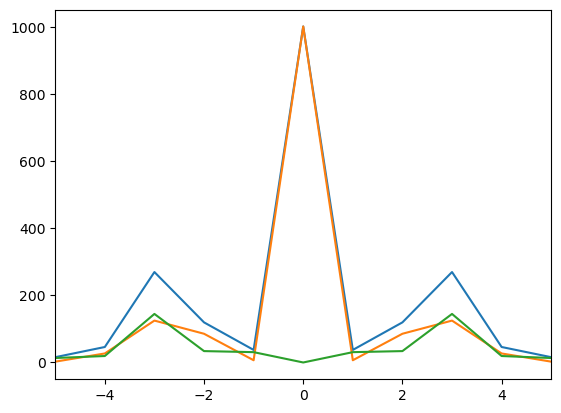

In [ ]:
ints_1  = np.abs(np.fft.fft(share*obj1))**2
ints_2 = np.abs(np.fft.fft((1-share)*obj2))**2
ints_12 = np.abs(np.fft.fft(share*obj1))*np.abs(np.fft.fft((1-share)*obj2))
ints_12_alt = np.abs(np.fft.fft(share*obj1)*np.fft.fft((1-share)*obj2))
# ints_1  = share*np.abs(np.fft.fft(obj1))**2
# ints_2 = (1-share)*np.abs(np.fft.fft(obj2))**2
# ints_12 = share*np.abs(np.fft.fft(obj1))*(1-share)*np.abs(np.fft.fft(obj2))
ints_comb = ints_1 + ints_2 + 2*ints_12
ints_mix = np.abs(np.fft.fft(obj_mix))**2
plt.figure()
plt.xlim(40,60)
plt.xlim(-5,5)
diff  =xline[1]-xline[0]
freq = np.fft.fftshift(np.fft.fftfreq(len(ints_1),diff))
plt.plot(freq,np.fft.fftshift(ints_comb), label = "|I1|^2+ |I2|^2 + 2|I1||I2| ")
plt.plot(freq,np.fft.fftshift(ints_mix), label = "|F(I)")
plt.plot(freq,np.fft.fftshift(ints_comb-ints_mix))

In [43]:
data.horse()

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

1.135605563476288
1.084906036925203


((128, 128), 16384, (128, 128), 16384)

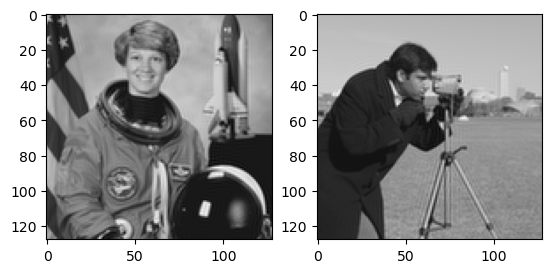

In [5]:
from skimage import data
from skimage.color import rgb2gray
from scipy.signal import decimate
image1= rgb2gray(data.astronaut())
image1 = decimate(decimate(image1,4, axis=1), 4, axis=0)
image2 = decimate(decimate((data.camera()),4, axis=1),4,axis=0)/255
print(np.max(image1))
print(np.max(image2))
fig, axs = plt.subplots(1,2)
make_kwargs = lambda **x : x 
kwargs = make_kwargs(cmap="gray")
axs[0].imshow(image1, **kwargs)
axs[1].imshow(image2,**kwargs)
image1.shape, image1.size, image2.shape, image2.size

In [6]:
def make_grid(
    image1,
    image2,
    sidelen = 5,
    obj_size = 128,
    share = 0.2,
    ordered=True
):
    selection_range = np.arange(sidelen**2)
    slc = slice(0,int(sidelen**2*share))
    if ordered:
        select = selection_range[slc]
    else:
        select_shuffle = selection_range.copy()
        np.random.shuffle(select_shuffle)
        select_shuffle=select_shuffle[slc]
        select = select_shuffle
    base_struc = np.arange(sidelen**2,dtype=float).reshape(sidelen,sidelen)
    base = base_struc.repeat(obj_size,axis=0).repeat(obj_size,axis=1)
    masks = []
    for idx in range(sidelen**2):
        mask = base==idx
        masks.append(mask)

    for idx in range(sidelen**2):

        if idx in select:
            base[masks[idx]] = image1.flatten()
        else:
            base[masks[idx]] = image2.ravel()
    return base
def make_mixed(image1,image2,share,sidelen=5):
    mixed_image = share*image1+(1-share)*image2
    tiled_image = np.tile(mixed_image, (sidelen,sidelen))
    return tiled_image

192629.9388115777
192629.93881157783
192629.9388115778


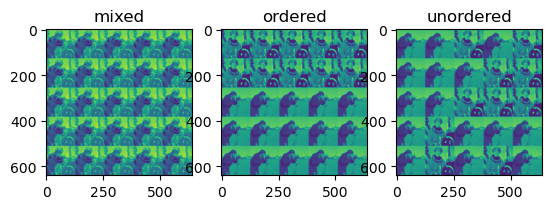

In [7]:
share=0.4
config = make_kwargs(
    share = 0.4,
    sidelen = 5
)
mixed = make_mixed(image1, image2, **config)
ordered = make_grid(image1,image2,**config)
unordered = make_grid(image1,image2,**config, ordered=False)
arrs = [mixed, ordered, unordered]
titles = ["mixed", "ordered", "unordered"]

fig, axs = plt.subplots(1,3)
for idx, arr in enumerate(arrs):
    ax = axs[idx]
    ax.set_title(titles[idx])
    ax.imshow(arr)
    print(np.sum(arr))


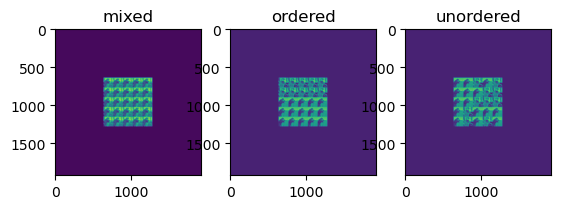

In [8]:
padlen = len(arr)

arrs_padded = [np.pad(arr,padlen) for arr in arrs]
fig, axs = plt.subplots(1,3)
for idx, arr in enumerate(arrs_padded):
    ax = axs[idx]
    ax.set_title(titles[idx])
    ax.imshow(arr)


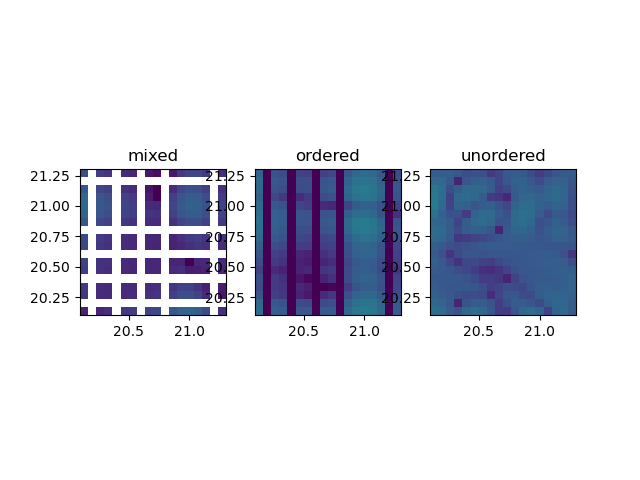

In [68]:
arrs_fft = [np.abs(np.fft.fft2(arr))**2 for arr in arrs_padded]
ext = len(image1)//2
spacing = len(arrs_padded[0])//len(image1)
hp = 1/2/spacing
extent = [-ext-hp,ext-hp,ext-hp,-ext-hp]
from matplotlib import colors 
fig, axs = plt.subplots(1,3)
norm =colors.LogNorm(1,np.max(arrs_fft))
for idx, arr in enumerate(arrs_fft):
    ax = axs[idx]
    ax.set_title(titles[idx])
    im = ax.imshow(np.fft.fftshift(arr),norm=norm, extent=extent)
    ax.set_xlim(20.1,21.3)
    ax.set_ylim(20.1,21.3)
    # plt.colorbar(im)



(1920, 1920)


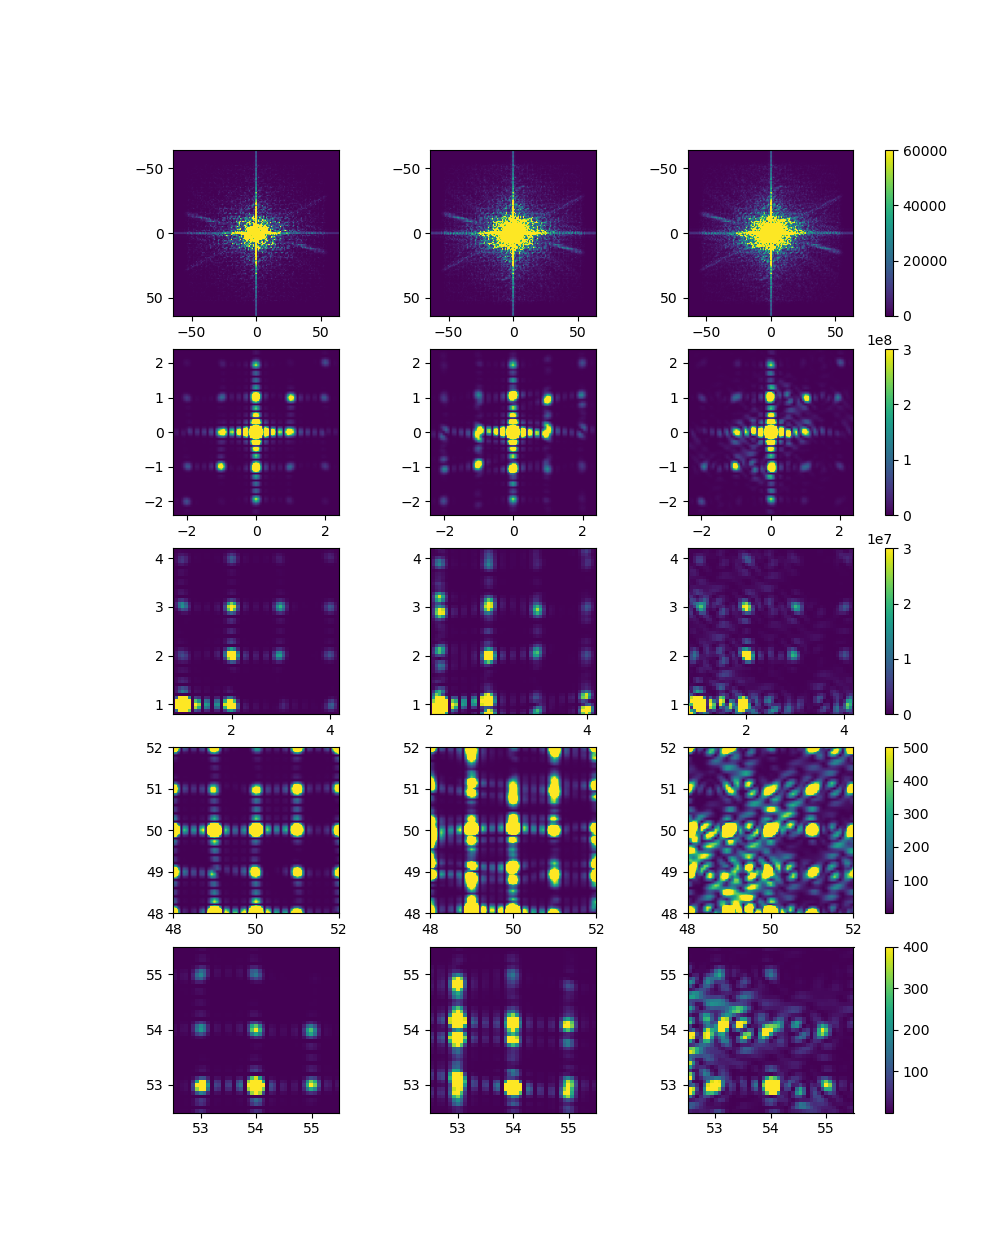

In [102]:
%matplotlib widget
print(arrs_fft[0].shape)
miniarr = np.array(arrs_fft)[:,900:1100, 900:1100]
vmax = np.max(miniarr)
lims = {
    "overview" : [None,None, 6e4],
    "center" : [-2.4,2.4, 3e8],
    "slightly off-center" : [.8,4.2, 3e7],
    "edge" : [48,52, 5e2],
    "very edge" : [52.5,55.5, 4e2],
    # "c" : [100,200, 6e2],
}
fig, axso = plt.subplots(len(lims),3, figsize=(10,len(lims)*2.5))
for axs,(title, attrs) in zip(axso,lims.items()):
    bot, top, vmax = attrs
    for idx, arr in enumerate(arrs_fft):
        ax = axs[idx]
        # ax.set_title(titles[idx])
        im = ax.imshow(np.fft.fftshift(arr), extent=extent)
        im.set_clim(vmax=vmax)
        ax.set_xlim(bot,top)
        ax.set_ylim(bot,top)
    fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.02, pad=0.04)


#     im.set_clim(vmax=3e6)
#     ax.set_xlim(1050,1070)
#     ax.set_ylim(1050,1070)
#     ax.set_xlim(100,200)
#     ax.set_ylim(100,200)
#     im.set_clim(vmax=5e2)
#     ax.set_xlim(140,170)
#     ax.set_ylim(140,170)
#     im.set_clim(vmax=5e2)
#     plt.colorbar(im)




15


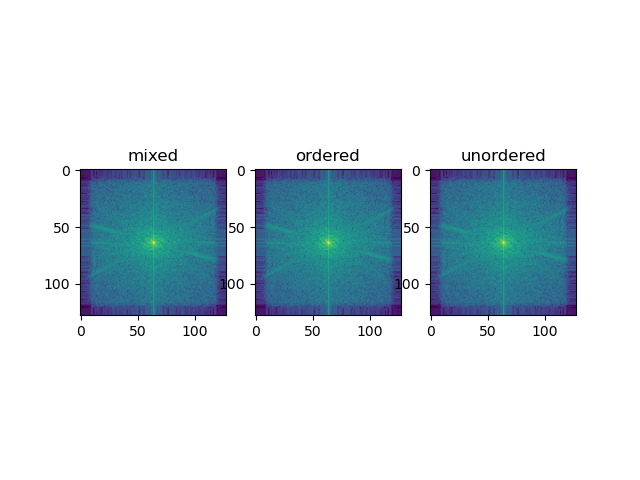

In [103]:
spacing = len(arrs_padded[0])//len(image1)
print(spacing)
arrs_bragg = [arr[::spacing,::spacing] for arr in arrs_fft]
fig, axs = plt.subplots(1,3)
for idx, arr in enumerate(arrs_bragg):
    ax = axs[idx]
    ax.set_title(titles[idx])
    ax.imshow(np.fft.fftshift(arr),norm=norm)


1.1920928955078125e-07


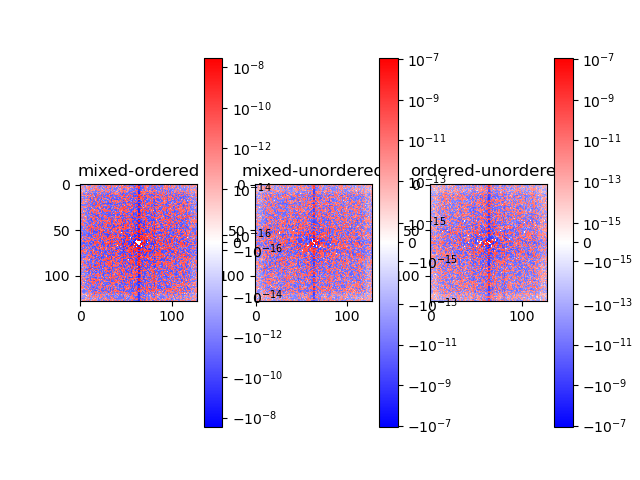

In [15]:
spacing = 2*config['sidelen']
arrs_diff = [
    arrs_bragg[0]-arrs_bragg[1],
    arrs_bragg[0]-arrs_bragg[2],
    arrs_bragg[1]-arrs_bragg[2],
]
print(np.max(arrs_diff))
fig, axs = plt.subplots(1,3)
title_diff = ["mixed-ordered", "mixed-unordered", "ordered-unordered"]
for idx, arr in enumerate(arrs_diff):
    ax = axs[idx]
    ax.set_title(title_diff[idx])
    vmax=np.max(np.abs(arr))
    snorm = colors.SymLogNorm(vmax/1e8, vmin=-vmax, vmax=vmax)
    im = ax.imshow(np.fft.fftshift(arr),cmap="bwr", norm=snorm)
    plt.colorbar(im)




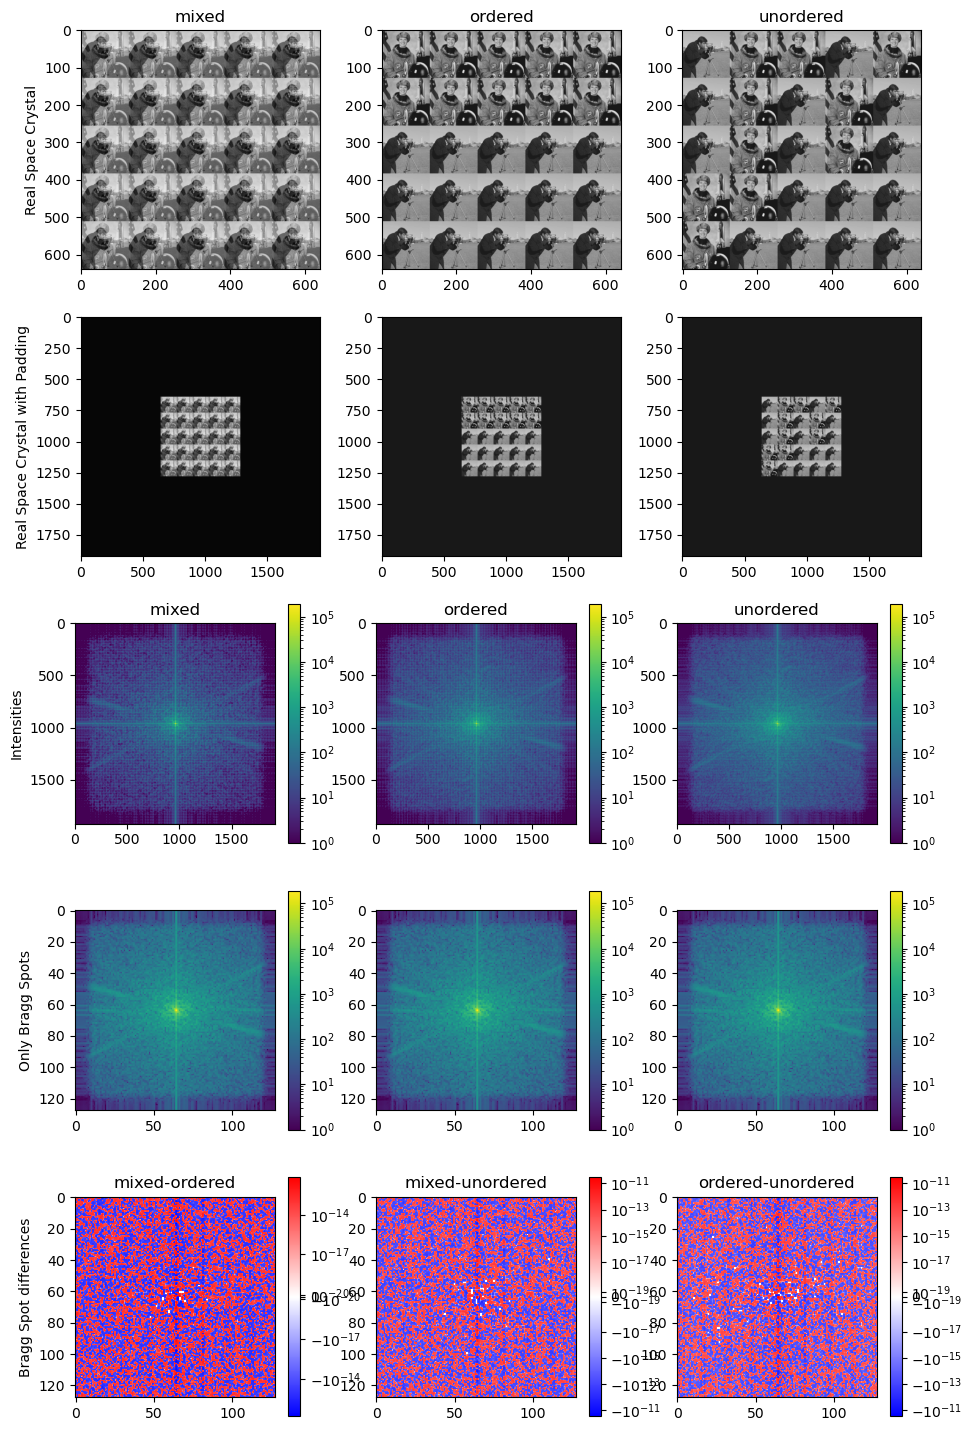

In [82]:

fig, axso = plt.subplots(5,3, figsize=(11,18), )
axs = axso[0]
axs[0].set_ylabel("Real Space Crystal")
for idx, arr in enumerate(arrs):
    ax = axs[idx]
    ax.set_title(titles[idx])
    ax.imshow(arr, cmap="grey")


axs = axso[1]
axs[0].set_ylabel("Real Space Crystal with Padding")
for idx, arr in enumerate(arrs_padded):
    ax = axs[idx]
    # ax.set_title(titles[idx])
    ax.imshow(arr, cmap="grey")


axs = axso[2]
axs[0].set_ylabel("Intensities")
for idx, arr in enumerate(arrs_fft):
    ax = axs[idx]
    ax.set_title(titles[idx])
    im = ax.imshow(np.fft.fftshift(arr),norm=norm)
    plt.colorbar(im)
axs = axso[3]
axs[0].set_ylabel("Only Bragg Spots")
for idx, arr in enumerate(arrs_bragg):
    ax = axs[idx]
    im = ax.imshow(np.fft.fftshift(arr),norm=norm)
    plt.colorbar(im)
axs = axso[4]
axs[0].set_ylabel("Bragg Spot differences")
for idx, arr in enumerate(arrs_diff):
    ax = axs[idx]
    vmax=np.max(np.abs(arr))
    ax.set_title(title_diff[idx])
    snorm = colors.SymLogNorm(vmax/1e8, vmin=-vmax, vmax=vmax)
    im = ax.imshow(np.fft.fftshift(arr),cmap="bwr", norm=snorm)
    plt.colorbar(im)
    im = ax.imshow(np.fft.fftshift(arr),cmap="bwr", norm=snorm)
# axs = axso[5]
# axs[0].set_ylabel("Ratio Bragg Spot differences/ Bragg intensities")
# for idx, (arr_d, arr_b) in enumerate(zip(arrs_diff, arrs_bragg)):
#     ax = axs[idx]
#     vmax=np.max(np.abs(arr))
#     ax.set_title(title_diff[idx])
#     snorm = colors.SymLogNorm(vmax/1e8, vmin=-vmax, vmax=vmax)
#     im = ax.imshow(np.fft.fftshift(arr_d/arr_b ),cmap="bwr", norm=snorm)
#     plt.colorbar(im)
#     # im = ax.imshow(np.fft.fftshift(arr),cmap="bwr", norm=snorm)

In [63]:
sidelen=5
arrs_shares = [make_grid(image1,image2,sidelen=sidelen, share=share, ordered=False) for share in [0.1, 0.2, 0.3]]
def get_arrs(arrs):
    arrs_padded = [np.pad(arr,padlen) for arr in arrs]
    arrs_fft = [np.abs(np.fft.fft2(arr))**2 for arr in arrs_padded]
    spacing = len(arrs_padded[0])//len(image1)
    arrs_bragg = [arr[::spacing,::spacing] for arr in arrs_fft]
    return arrs_padded, arrs_fft, arrs_bragg
a_pad, a_fft, a_bragg = get_arrs(arrs_shares)

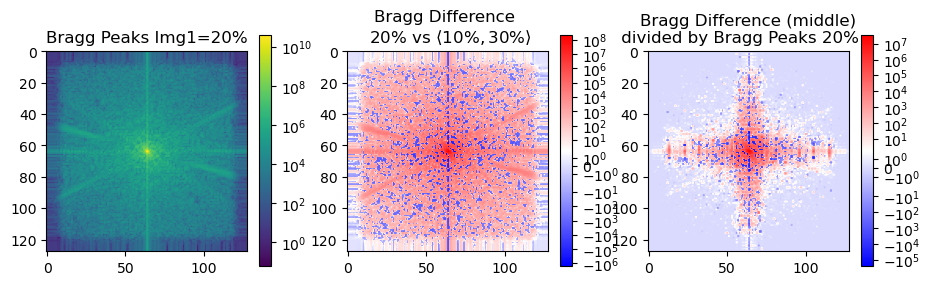

In [69]:
a_mean = (a_bragg[0]+a_bragg[2])/2
a_mean = ((np.sqrt(a_bragg[0])+np.sqrt(a_bragg[2]))/2)**2
a_diff = a_mean-a_bragg[1]
fig, axs = plt.subplots(1,3, figsize=(11,3))
ax=axs[0]
ax.set_title(f"Bragg Peaks Img1={0.2:.0%}")
im = ax.imshow(np.fft.fftshift(a_bragg[1]), norm="log")
plt.colorbar(im)
ax=axs[1]
ax.set_title("Bragg Difference \n 20% vs "+r"$\langle 10\%,30\%\rangle$")
im = ax.imshow(np.fft.fftshift(a_diff), norm="symlog", cmap="bwr")
plt.colorbar(im)
ax=axs[2]
ax.set_title("Bragg Difference (middle)\n divided by Bragg Peaks 20%    ")
im = ax.imshow(np.fft.fftshift(a_diff)/a_bragg[1], norm="symlog", cmap="bwr")
plt.colorbar(im)


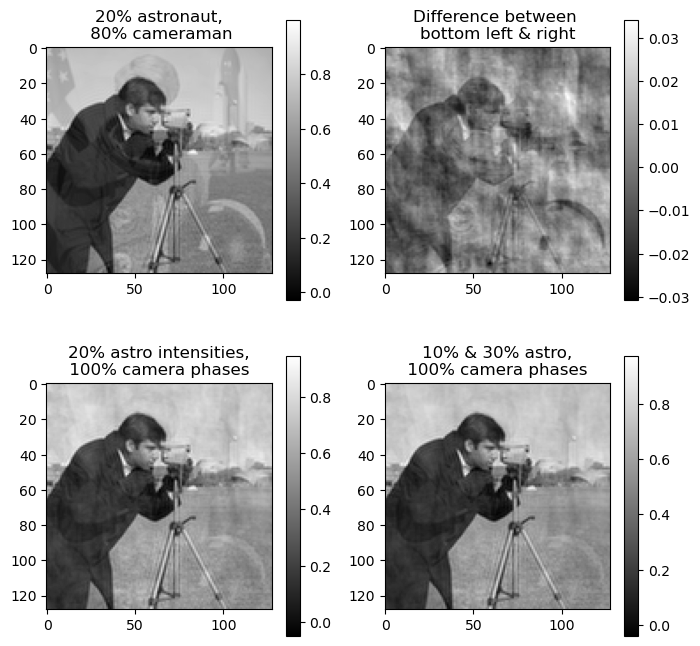

In [72]:
phases0 = np.angle(np.fft.fft2(image2))
a20 = np.fft.ifft2(np.sqrt(a_bragg[1])*np.exp(1j*phases0)).real/sidelen**2
a1030 = np.fft.ifft2(np.sqrt(a_mean)*np.exp(1j*phases0)).real/sidelen**2
fig, axs = plt.subplots(2,2,figsize=(8,8))
kwargs= make_kwargs(cmap="grey")
ax = axs[0,0]
ax.set_title("20% astronaut,\n 80% cameraman")
im = ax.imshow(image1*0.2+image2*0.8, **kwargs)
plt.colorbar(im)
ax = axs[0,1]
ax.set_title("Difference between \nbottom left & right")
im = ax.imshow(a1030-a20, **kwargs)
plt.colorbar(im)
ax = axs[1,0]
ax.set_title("20% astro intensities,\n 100% camera phases ")
im = ax.imshow(a20, **kwargs)
plt.colorbar(im)
ax = axs[1,1]
ax.set_title("10% & 30% astro,\n 100% camera phases ")
im = ax.imshow(a1030, **kwargs)
plt.colorbar(im)
# plt.imshow(np.fft.ifft2(a_bragg[1]*np.exp(1j*phases0)).real)